# NEO Region — Census Demographic Profile
# ACS 5-Year Estimates, 2024 | 7 Counties
# Source: U.S. Census Bureau via data.census.gov API


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import requests
import os
import warnings
warnings.filterwarnings("ignore")

CHARTS_PATH = r"C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\02_Census_Demographics\charts"
os.makedirs(CHARTS_PATH, exist_ok=True)

# Set CENSUS_API_KEY as an environment variable before running:
#   Windows: $env:CENSUS_API_KEY = "your_key"
#   Mac/Linux: export CENSUS_API_KEY="your_key"
CENSUS_KEY = os.environ.get("CENSUS_API_KEY", "")
ACS_URL    = "https://api.census.gov/data/2024/acs/acs5"

COUNTY_FIPS = {
    "Cuyahoga": "035",
    "Summit":   "153",
    "Stark":    "151",
    "Lorain":   "093",
    "Lake":     "085",
    "Medina":   "103",
    "Portage":  "133",
}
FIPS_STR = ",".join(COUNTY_FIPS.values())

VARIABLES = [
    "NAME",
    "B01003_001E",
    "B19013_001E",
    "B15003_001E",
    "B15003_022E", "B15003_023E",
    "B15003_024E", "B15003_025E",
    "B01001_001E",
    "B01001_011E", "B01001_012E",
    "B01001_013E", "B01001_014E",
    "B01001_035E", "B01001_036E",
    "B01001_037E", "B01001_038E",
    "B23025_002E",
    "B23025_005E",
]

resp = requests.get(ACS_URL, params={
    "get": ",".join(VARIABLES),
    "for": f"county:{FIPS_STR}",
    "in":  "state:39",
    "key": CENSUS_KEY,
})
resp.raise_for_status()

raw    = resp.json()
cols   = raw[0]
rows   = raw[1:]
raw_df = pd.DataFrame(rows, columns=cols)

num_cols = [c for c in cols if c not in ("NAME", "state", "county")]
raw_df[num_cols] = raw_df[num_cols].apply(pd.to_numeric)

raw_df["County"] = raw_df["NAME"].str.replace(" County, Ohio", "", regex=False)

raw_df["bach_plus_pct"] = (
    (raw_df["B15003_022E"] + raw_df["B15003_023E"] +
     raw_df["B15003_024E"] + raw_df["B15003_025E"])
    / raw_df["B15003_001E"] * 100
).round(1)

raw_df["pop_25_44"] = (
    raw_df["B01001_011E"] + raw_df["B01001_012E"] +
    raw_df["B01001_013E"] + raw_df["B01001_014E"] +
    raw_df["B01001_035E"] + raw_df["B01001_036E"] +
    raw_df["B01001_037E"] + raw_df["B01001_038E"]
)
raw_df["pct_25_44"]  = (raw_df["pop_25_44"] / raw_df["B01001_001E"] * 100).round(1)
raw_df["unemp_rate"] = (raw_df["B23025_005E"] / raw_df["B23025_002E"] * 100).round(1)

df = raw_df[[
    "County", "B01003_001E", "B19013_001E",
    "bach_plus_pct", "pct_25_44", "unemp_rate"
]].rename(columns={
    "B01003_001E": "population",
    "B19013_001E": "median_hh_inc",
}).sort_values("population", ascending=False).reset_index(drop=True)

print(f"Live data fetched for {len(df)} counties  |  ACS 5-Year Estimates, 2024")
print(f"API endpoint : {ACS_URL}")
print(f"Charts path  : {CHARTS_PATH}")


Live data fetched for 7 counties  |  ACS 5-Year Estimates, 2024
API endpoint : https://api.census.gov/data/2024/acs/acs5
Charts path  : C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\02_Census_Demographics\charts


In [2]:
# ── COMPARISON TABLE ────────────────────────────────────────────────────────
pop_wt       = df["population"] / df["population"].sum()
region_inc   = (df["median_hh_inc"] * pop_wt).sum()
region_bach  = (df["bach_plus_pct"] * pop_wt).sum()
region_2544  = (df["pct_25_44"]     * pop_wt).sum()
region_unemp = (df["unemp_rate"]    * pop_wt).sum()

print("=" * 82)
print("  NEO REGION — DEMOGRAPHIC COMPARISON  |  ACS 5-Year Estimates, 2024")
print("=" * 82)
print(f"  {'County':<12} {'Population':>13} {'Med HH Inc':>12} {'Bach+ (%)':>10} {'25-44 (%)':>10} {'Unemp (%)':>10}")
print("-" * 82)
for _, row in df.iterrows():
    print(f"  {row['County']:<12} {int(row['population']):>13,}  "
          f"${int(row['median_hh_inc']):>10,}  "
          f"{row['bach_plus_pct']:>9.1f}%  "
          f"{row['pct_25_44']:>9.1f}%  "
          f"{row['unemp_rate']:>9.1f}%")
print("-" * 82)
print(f"  {'REGION':12} {df['population'].sum():>13,}  "
      f"${region_inc:>10,.0f}  "
      f"{region_bach:>9.1f}%  "
      f"{region_2544:>9.1f}%  "
      f"{region_unemp:>9.1f}%  (pop-weighted)")
print("=" * 82)
print("Source: U.S. Census Bureau, ACS 5-Year Estimates 2024 | data.census.gov")


  NEO REGION — DEMOGRAPHIC COMPARISON  |  ACS 5-Year Estimates, 2024
  County          Population   Med HH Inc  Bach+ (%)  25-44 (%)  Unemp (%)
----------------------------------------------------------------------------------
  Cuyahoga         1,245,873  $    64,468       36.5%       26.8%        6.6%
  Summit             537,864  $    71,622       35.8%       25.9%        5.1%
  Stark              373,713  $    67,934       25.9%       24.1%        3.9%
  Lorain             317,129  $    73,347       28.5%       23.9%        4.3%
  Lake               232,216  $    80,925       31.6%       23.9%        3.9%
  Medina             183,660  $    94,968       36.2%       23.5%        2.9%
  Portage            161,956  $    75,766       32.5%       23.2%        5.3%
----------------------------------------------------------------------------------
  REGION           3,052,411  $    70,762       33.6%       25.4%        5.3%  (pop-weighted)
Source: U.S. Census Bureau, ACS 5-Year Estimates 2

Chart 1 saved: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\02_Census_Demographics\charts\neo_census_chart1_comparison.png


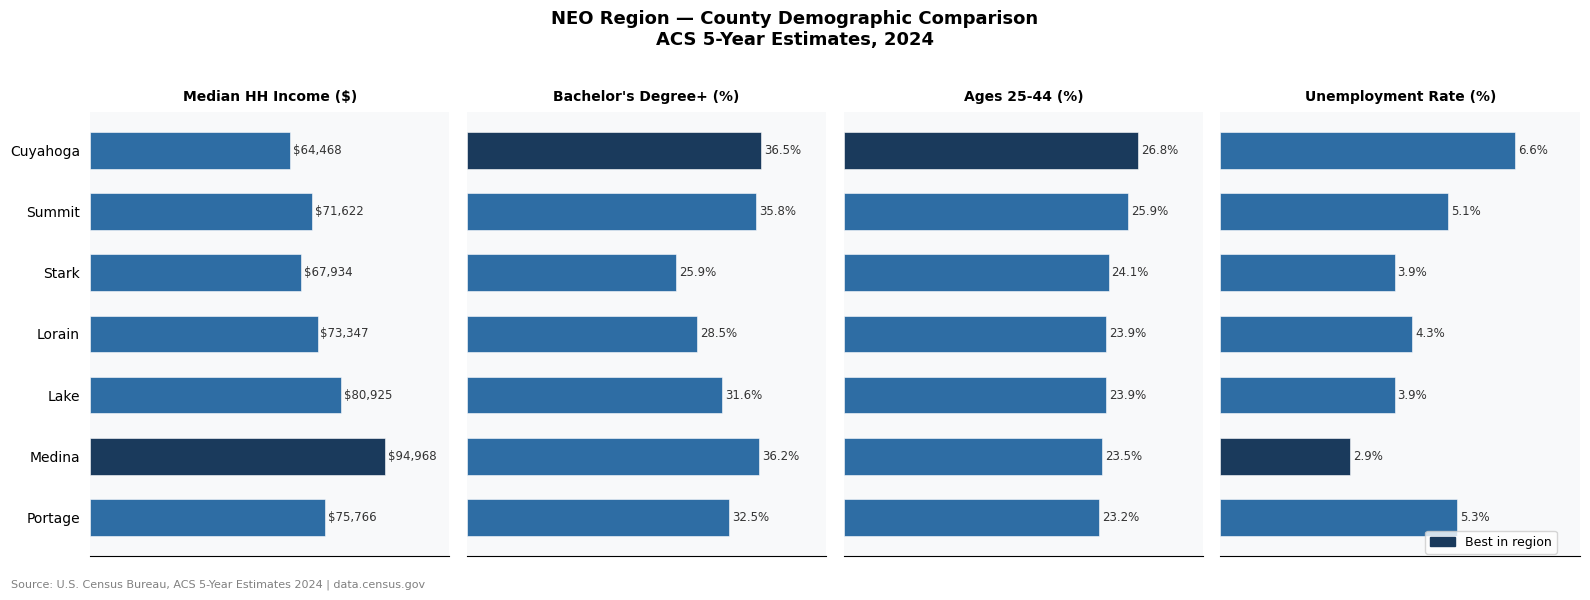

In [3]:
# ── CHART 1: COMPARISON TABLE (Visual Heatmap-Style Bar Grid) ──────────────
metrics = [
    ("median_hh_inc", "Median HH Income ($)",  "${:,.0f}", False),
    ("bach_plus_pct", "Bachelor's Degree+ (%)", "{:.1f}%",  False),
    ("pct_25_44",     "Ages 25-44 (%)",          "{:.1f}%",  False),
    ("unemp_rate",    "Unemployment Rate (%)",   "{:.1f}%",  True),
]

bar_color = "#2e6da4"
highlight = "#1a3a5c"

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5.5), sharey=False)
fig.patch.set_facecolor("white")

for ax, (col, label, fmt, lower_better) in zip(axes, metrics):
    vals     = df[col].values
    best_idx = vals.argmin() if lower_better else vals.argmax()
    colors   = [highlight if i == best_idx else bar_color for i in range(len(df))]

    bars  = ax.barh(df["County"][::-1], vals[::-1], color=colors[::-1],
                    edgecolor="white", linewidth=0.4, height=0.6)
    x_max = vals.max()
    for bar, v in zip(bars, vals[::-1]):
        ax.text(bar.get_width() + x_max * 0.01,
                bar.get_y() + bar.get_height() / 2,
                fmt.format(v), va="center", fontsize=8.5, color="#333")

    ax.set_title(label, fontsize=10, fontweight="bold", pad=8)
    ax.set_facecolor("#f8f9fa")
    ax.spines[["top","right","left"]].set_visible(False)
    ax.tick_params(left=False)
    ax.set_xlim(0, x_max * 1.22)
    ax.xaxis.set_visible(False)
    if ax != axes[0]:
        ax.set_yticklabels([])
    else:
        ax.tick_params(labelsize=10)

best_patch = mpatches.Patch(color=highlight, label="Best in region")
fig.legend(handles=[best_patch], loc="lower right", fontsize=9,
           framealpha=0.8, bbox_to_anchor=(0.98, 0.02))
fig.suptitle("NEO Region — County Demographic Comparison\nACS 5-Year Estimates, 2024",
             fontsize=13, fontweight="bold", y=1.02)
fig.text(0.01, -0.03,
         "Source: U.S. Census Bureau, ACS 5-Year Estimates 2024 | data.census.gov",
         fontsize=8, color="gray")
plt.tight_layout()
chart1_path = os.path.join(CHARTS_PATH, "neo_census_chart1_comparison.png")
plt.savefig(chart1_path, dpi=150, bbox_inches="tight")
print(f"Chart 1 saved: {chart1_path}")
plt.show()


Chart 2 saved: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\02_Census_Demographics\charts\neo_census_chart2_income_vs_education.png


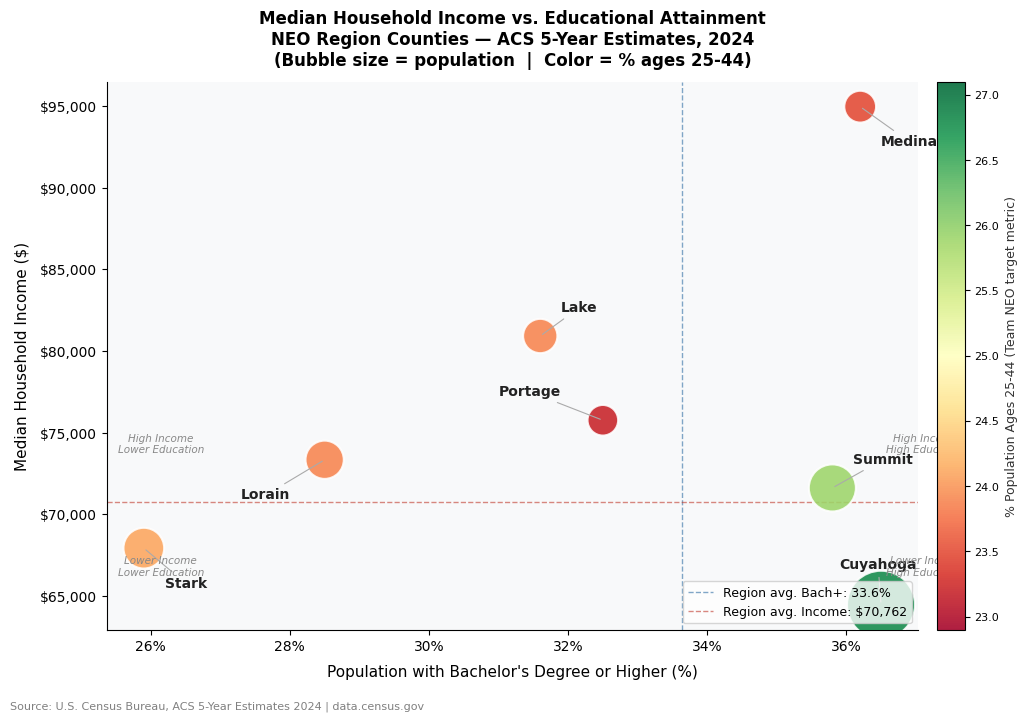

In [4]:
# ── CHART 2: MEDIAN HH INCOME vs. BACHELOR'S DEGREE % (Bubble Scatter) ────
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

pop_norm  = df["population"] / df["population"].max()
bubble_sz = (pop_norm * 2200 + 200).values

color_vals = df["pct_25_44"].values
norm       = plt.Normalize(color_vals.min() - 0.3, color_vals.max() + 0.3)
cmap       = plt.cm.RdYlGn

sc = ax.scatter(
    df["bach_plus_pct"], df["median_hh_inc"],
    s=bubble_sz, c=color_vals, cmap=cmap, norm=norm,
    edgecolors="white", linewidths=1.5, alpha=0.88, zorder=3
)

offsets = {
    "Cuyahoga": (-0.6,  2200),
    "Summit":   ( 0.3,  1500),
    "Stark":    ( 0.3, -2400),
    "Lorain":   (-1.2, -2400),
    "Lake":     ( 0.3,  1500),
    "Medina":   ( 0.3, -2400),
    "Portage":  (-1.5,  1500),
}
for _, row in df.iterrows():
    dx, dy = offsets.get(row["County"], (0.3, 1000))
    ax.annotate(row["County"],
                xy=(row["bach_plus_pct"], row["median_hh_inc"]),
                xytext=(row["bach_plus_pct"] + dx, row["median_hh_inc"] + dy),
                fontsize=10, fontweight="bold", color="#222",
                arrowprops=dict(arrowstyle="-", color="#aaa", lw=0.8))

ax.axvline(region_bach, color="#2e6da4", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Region avg. Bach+: {region_bach:.1f}%")
ax.axhline(region_inc,  color="#c0392b", linestyle="--", linewidth=1, alpha=0.6,
           label=f"Region avg. Income: ${region_inc:,.0f}")

cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("% Population Ages 25-44 (Team NEO target metric)", fontsize=9, color="#333")
cbar.ax.tick_params(labelsize=8)

ax.set_xlabel("Population with Bachelor's Degree or Higher (%)", fontsize=11, labelpad=8)
ax.set_ylabel("Median Household Income ($)", fontsize=11, labelpad=8)
ax.set_title("Median Household Income vs. Educational Attainment\n"
             "NEO Region Counties — ACS 5-Year Estimates, 2024\n"
             "(Bubble size = population  |  Color = % ages 25-44)",
             fontsize=12, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=9, loc="lower right", framealpha=0.8)

x_mid, y_mid = region_bach, region_inc
for (xoff, yoff, label) in [
    (-7.5,  3000, "High Income\nLower Education"),
    ( 3.5,  3000, "High Income\nHigh Education"),
    (-7.5, -4500, "Lower Income\nLower Education"),
    ( 3.5, -4500, "Lower Income\nHigh Education"),
]:
    ax.text(x_mid + xoff, y_mid + yoff, label,
            fontsize=7.5, color="#888", ha="center", style="italic")

fig.text(0.01, -0.02,
         "Source: U.S. Census Bureau, ACS 5-Year Estimates 2024 | data.census.gov",
         fontsize=8, color="gray")
plt.tight_layout()
chart2_path = os.path.join(CHARTS_PATH, "neo_census_chart2_income_vs_education.png")
plt.savefig(chart2_path, dpi=150, bbox_inches="tight")
print(f"Chart 2 saved: {chart2_path}")
plt.show()


In [5]:
# ── KEY INSIGHTS ────────────────────────────────────────────────────────────
print("=" * 65)
print("  KEY INSIGHTS — Team NEO Lens")
print("=" * 65)

top_edu   = df.loc[df["bach_plus_pct"].idxmax()]
top_inc   = df.loc[df["median_hh_inc"].idxmax()]
top_2544  = df.loc[df["pct_25_44"].idxmax()]
low_unemp = df.loc[df["unemp_rate"].idxmin()]
low_2544  = df.loc[df["pct_25_44"].idxmin()]

print(f"  Highest education   : {top_edu['County']} ({top_edu['bach_plus_pct']:.1f}% bach+)")
print(f"  Highest income      : {top_inc['County']} (${top_inc['median_hh_inc']:,})")
print(f"  Strongest 25-44 %   : {top_2544['County']} ({top_2544['pct_25_44']:.1f}%)")
print(f"  Lowest unemp.       : {low_unemp['County']} ({low_unemp['unemp_rate']:.1f}%)")
print(f"  Weakest 25-44 %     : {low_2544['County']} ({low_2544['pct_25_44']:.1f}%)")
print()

cuya = df[df["County"] == "Cuyahoga"].iloc[0]
medi = df[df["County"] == "Medina"].iloc[0]
summ = df[df["County"] == "Summit"].iloc[0]

print("  BEND-THE-CURVE TENSIONS:")
print(f"  - Cuyahoga has the 2nd-highest bach+ rate ({cuya['bach_plus_pct']:.1f}%) but only")
print(f"    {cuya['pct_25_44']:.1f}% aged 25-44 — education is not translating into retention.")
print(f"  - Medina leads in both income (${medi['median_hh_inc']:,}) and bach+ ({medi['bach_plus_pct']:.1f}%)")
print(f"    yet its 25-44 share ({medi['pct_25_44']:.1f}%) trails Summit ({summ['pct_25_44']:.1f}%),")
print(f"    suggesting Medina attracts established professionals, not young talent.")
print(f"  - Summit has the strongest 25-44 share ({summ['pct_25_44']:.1f}%) with a")
print(f"    solid bach+ base ({summ['bach_plus_pct']:.1f}%) — likely the healthiest talent pipeline.")
print()
print("=" * 65)
print(f"  Charts saved to: {CHARTS_PATH}")
print("=" * 65)


  KEY INSIGHTS — Team NEO Lens
  Highest education   : Cuyahoga (36.5% bach+)
  Highest income      : Medina ($94,968)
  Strongest 25-44 %   : Cuyahoga (26.8%)
  Lowest unemp.       : Medina (2.9%)
  Weakest 25-44 %     : Portage (23.2%)

  BEND-THE-CURVE TENSIONS:
  - Cuyahoga has the 2nd-highest bach+ rate (36.5%) but only
    26.8% aged 25-44 — education is not translating into retention.
  - Medina leads in both income ($94,968) and bach+ (36.2%)
    yet its 25-44 share (23.5%) trails Summit (25.9%),
    suggesting Medina attracts established professionals, not young talent.
  - Summit has the strongest 25-44 share (25.9%) with a
    solid bach+ base (35.8%) — likely the healthiest talent pipeline.

  Charts saved to: C:\Users\akash\Downloads\TeamNEO_Research_Portfolio\02_Census_Demographics\charts
